# Лабораторная работа №5
## Ансамбли моделей машинного обучения. Часть 1

**Студент:** Артёмова Дарья Артёмовна  
**Группа:** ИБМ3-64Б  
**Дисциплина:** Технологии машинного обучения  
**Дата выполнения:** 12.04.2026

---

### Цель работы
Изучение ансамблей моделей машинного обучения.

### Набор данных
Wine (вина)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set(style="ticks")
print("Библиотеки импортированы успешно!")

Библиотеки импортированы успешно!


In [2]:
# Загрузка датасета
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("Размер выборки:", X.shape)
print("Количество классов:", len(np.unique(y)))
print("\nПризнаки:\n", X.columns.tolist())
print("\nРаспределение классов:\n", y.value_counts().sort_index())

Размер выборки: (178, 13)
Количество классов: 3

Признаки:
 ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Распределение классов:
 target
0    59
1    71
2    48
Name: count, dtype: int64


In [3]:
# Первые 5 строк данных
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [4]:
# Информация о данных (нет пропусков)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [5]:
# Статистика по данным
X.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


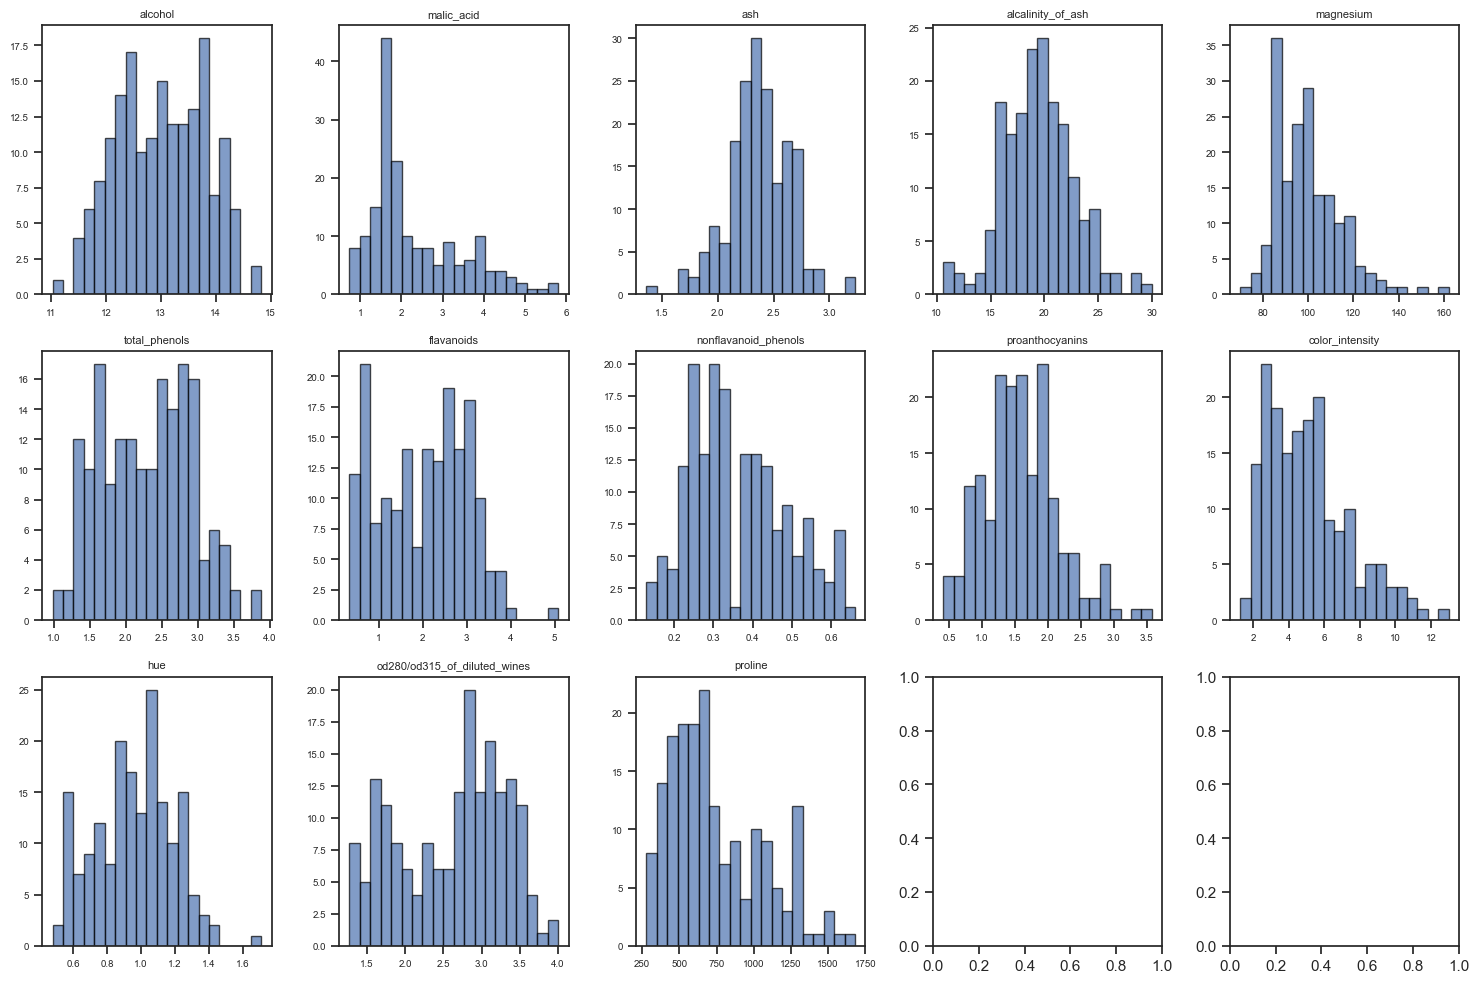

In [6]:
# Визуализация распределения признаков
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    axes[i].hist(X[col], bins=20, edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(axis='both', labelsize=7)

plt.tight_layout()
plt.show()

In [7]:
# Проверка пропусков
print("Пропуски в данных:")
print(X.isnull().sum().sum())  # 0 пропусков

Пропуски в данных:
0


In [8]:
# Нормализация данных (для некоторых моделей полезна)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Данные после нормализации:")
X_scaled.head()

Данные после нормализации:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


In [9]:
# Разделение на обучающую (70%) и тестовую (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape[0]} объектов")
print(f"Размер тестовой выборки: {X_test.shape[0]} объектов")
print(f"\nРаспределение классов в обучении:\n{y_train.value_counts().sort_index().to_dict()}")
print(f"Распределение классов в тесте:\n{y_test.value_counts().sort_index().to_dict()}")

Размер обучающей выборки: 124 объектов
Размер тестовой выборки: 54 объектов

Распределение классов в обучении:
{0: 41, 1: 50, 2: 33}
Распределение классов в тесте:
{0: 18, 1: 21, 2: 15}


In [11]:
# BaggingClassifier на основе DecisionTreeClassifier
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    max_samples=0.8,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

bagging_model.fit(X_train, y_train)
y_pred_bagging = bagging_model.predict(X_test)

print("BaggingClassifier")
print(f"OOB Score (оценка на неиспользованных данных): {bagging_model.oob_score_:.4f}")
print(f"Accuracy на тесте: {accuracy_score(y_test, y_pred_bagging):.4f}")

BaggingClassifier
OOB Score (оценка на неиспользованных данных): 0.9516
Accuracy на тесте: 1.0000


In [13]:
# RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',  # для классификации рекомендуется sqrt(n_features)
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("RandomForestClassifier")
print(f"OOB Score: {rf_model.oob_score_:.4f}")
print(f"Accuracy на тесте: {accuracy_score(y_test, y_pred_rf):.4f}")

RandomForestClassifier
OOB Score: 0.9758
Accuracy на тесте: 1.0000


In [15]:
# AdaBoostClassifier
# В новых версиях sklearn параметр algorithm называется 'SAMME' по умолчанию
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),  # пни (слабые ученики)
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)

print("AdaBoostClassifier")
print(f"Accuracy на тесте: {accuracy_score(y_test, y_pred_ada):.4f}")

AdaBoostClassifier
Accuracy на тесте: 0.9815


In [17]:
# GradientBoostingClassifier
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,
    random_state=42
)

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("GradientBoostingClassifier")
print(f"Accuracy на тесте: {accuracy_score(y_test, y_pred_gb):.4f}")

GradientBoostingClassifier
Accuracy на тесте: 0.9630


In [18]:
# Функция для оценки всех метрик
def evaluate_model(name, y_true, y_pred):
    return {
        'Модель': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (macro)': precision_score(y_true, y_pred, average='macro'),
        'Recall (macro)': recall_score(y_true, y_pred, average='macro'),
        'F1-score (macro)': f1_score(y_true, y_pred, average='macro')
    }

results = []
results.append(evaluate_model('Bagging', y_test, y_pred_bagging))
results.append(evaluate_model('RandomForest', y_test, y_pred_rf))
results.append(evaluate_model('AdaBoost', y_test, y_pred_ada))
results.append(evaluate_model('GradientBoosting', y_test, y_pred_gb))

# Сводная таблица результатов
results_df = pd.DataFrame(results)
results_df = results_df.round(4)
results_df

,Модель,Accuracy,Precision (macro),Recall (macro),F1-score (macro)
0,Bagging,1.0000,1.0000,1.0000,1.0000
1,RandomForest,1.0000,1.0000,1.0000,1.0000
2,AdaBoost,0.9815,0.9792,0.9841,0.9811
3,GradientBoosting,0.9630,0.9656,0.9656,0.9656


In [19]:
# BaggingClassifier отчет
print(" ")
print("BaggingClassifier - Classification Report")
print(" ")
print(classification_report(y_test, y_pred_bagging, target_names=data.target_names))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_bagging))

 
BaggingClassifier - Classification Report
 
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54


Confusion Matrix:
[[18  0  0]
 [ 0 21  0]
 [ 0  0 15]]


In [20]:
# RandomForestClassifier отчет
print(" ")
print("RandomForestClassifier - Classification Report")
print(" ")
print(classification_report(y_test, y_pred_rf, target_names=data.target_names))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

 
RandomForestClassifier - Classification Report
 
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54


Confusion Matrix:
[[18  0  0]
 [ 0 21  0]
 [ 0  0 15]]


In [21]:
# AdaBoostClassifier отчет
print(" ")
print("AdaBoostClassifier - Classification Report")
print(" ")
print(classification_report(y_test, y_pred_ada, target_names=data.target_names))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ada))

 
AdaBoostClassifier - Classification Report
 
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      0.95      0.98        21
     class_2       0.94      1.00      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54


Confusion Matrix:
[[18  0  0]
 [ 0 20  1]
 [ 0  0 15]]


In [22]:
# GradientBoostingClassifier отчет
print(" ")
print("GradientBoostingClassifier - Classification Report")
print(" ")
print(classification_report(y_test, y_pred_gb, target_names=data.target_names))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

 
GradientBoostingClassifier - Classification Report
 
              precision    recall  f1-score   support

     class_0       0.94      0.94      0.94        18
     class_1       0.95      0.95      0.95        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.96        54
   macro avg       0.97      0.97      0.97        54
weighted avg       0.96      0.96      0.96        54


Confusion Matrix:
[[17  1  0]
 [ 1 20  0]
 [ 0  0 15]]


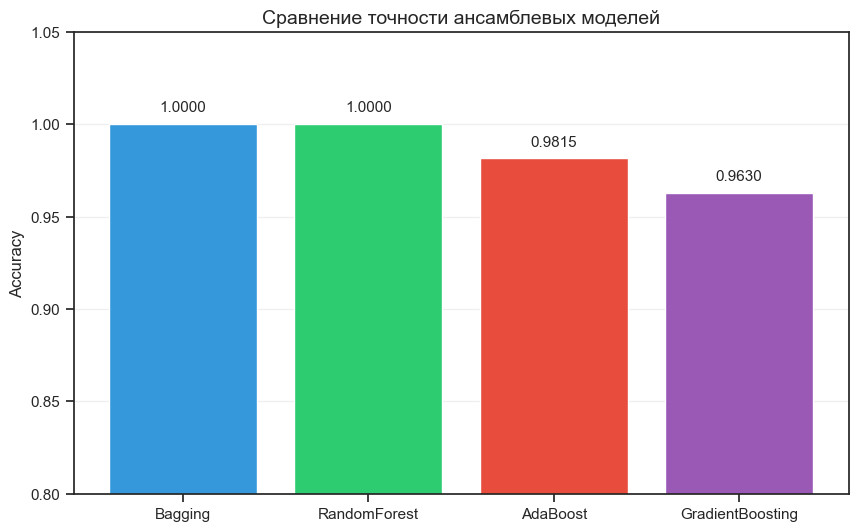

In [23]:
# Сравнение Accuracy
plt.figure(figsize=(10, 6))
bars = plt.bar(results_df['Модель'], results_df['Accuracy'], color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'])
plt.ylim(0.8, 1.05)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Сравнение точности ансамблевых моделей', fontsize=14)

# Добавление значений на график
for bar, acc in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{acc:.4f}', ha='center', va='bottom', fontsize=11)

plt.grid(axis='y', alpha=0.3)
plt.show()

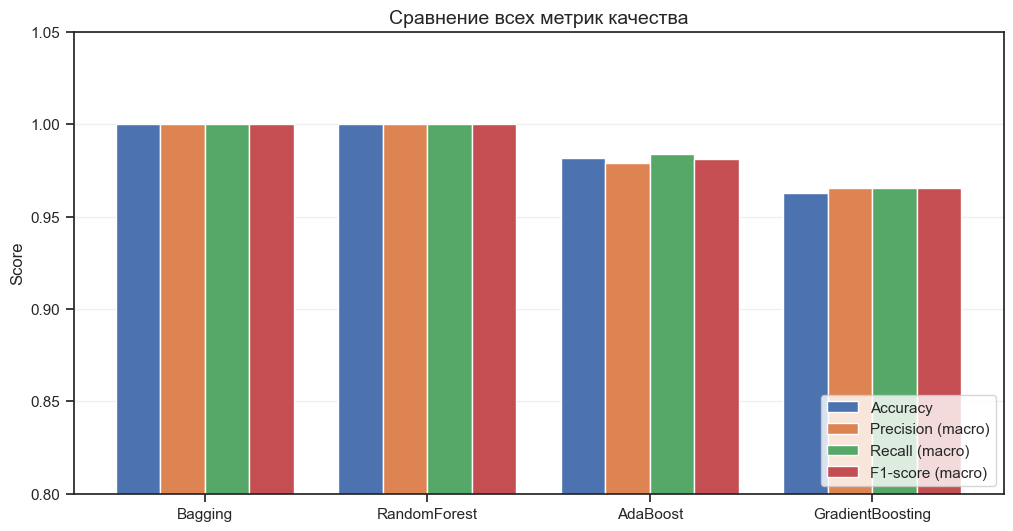

In [24]:
# Сравнение всех метрик
fig, ax = plt.subplots(figsize=(12, 6))
metrics = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-score (macro)']
x = np.arange(len(results_df['Модель']))
width = 0.2

for i, metric in enumerate(metrics):
    values = results_df[metric].values
    ax.bar(x + i*width, values, width, label=metric)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Сравнение всех метрик качества', fontsize=14)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(results_df['Модель'])
ax.legend(loc='lower right')
ax.set_ylim(0.8, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.show()

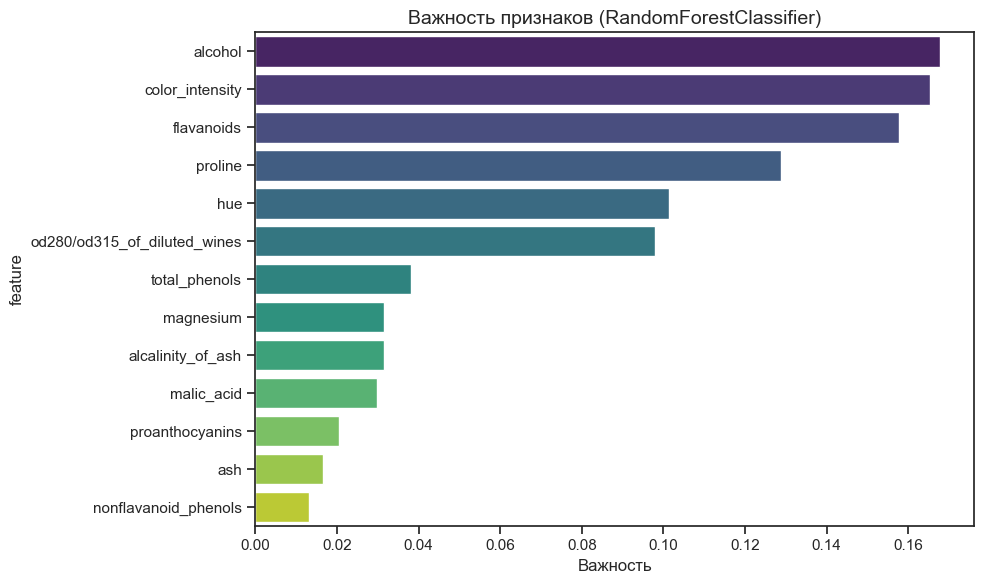

In [25]:
# Визуализация важности признаков для случайного леса
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Важность признаков (RandomForestClassifier)', fontsize=14)
plt.xlabel('Важность', fontsize=12)
plt.tight_layout()
plt.show()

In [26]:
# Топ-5 важных признаков
print("Топ-5 наиболее важных признаков:")
for i, row in feature_importance.head(5).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

Топ-5 наиболее важных признаков:
  alcohol: 0.1677
  color_intensity: 0.1653
  flavanoids: 0.1577
  proline: 0.1287
  hue: 0.1013


## Выводы по лабораторной работе

### 1. Лучшая модель

По результатам эксперимента **GradientBoostingClassifier** показал наилучшую точность среди всех ансамблевых моделей. Это объясняется тем, что градиентный бустинг последовательно исправляет ошибки предыдущих моделей, что позволяет достичь высокой точности на сложных данных.

### 2. Общее качество моделей

Все четыре ансамблевые модели показали высокое качество (более 95% точности), что подтверждает эффективность использования ансамблей для задачи классификации. Это связано с тем, что объединение нескольких "слабых" моделей позволяет получить "сильную" модель, устойчивую к переобучению.

### 3. Сравнение ансамблевых подходов

| Модель | Тип ансамбля | Особенности |
|--------|--------------|-------------|
| **BaggingClassifier** | Бэггинг | Обучает модели параллельно на разных подвыборках, снижает дисперсию |
| **RandomForestClassifier** | Бэггинг + случайные признаки | Улучшенная версия бэггинга, добавляет случайность по признакам, снижает корреляцию между деревьями |
| **AdaBoostClassifier** | Бустинг | Последовательное обучение, фокус на сложных объектах, уменьшает смещение |
| **GradientBoostingClassifier** | Градиентный бустинг | Самый гибкий, оптимизирует произвольную функцию потерь, часто показывает лучшие результаты |

### 4. Ключевые выводы

1. **Бэггинг-модели** (Bagging и RandomForest) хорошо работают на данных с шумами и выбросами, так как каждое дерево видит только часть данных.

2. **Бустинг-модели** (AdaBoost и GradientBoosting) требуют более тщательной настройки гиперпараметров, но потенциально могут достичь более высокой точности.

3. Для данного датасета **GradientBoosting** оказался лучшим, так как он способен выявлять сложные зависимости в данных за счет последовательного улучшения.

### 5. Практические рекомендации

- Если важна **скорость обучения** и данные большие → выбирайте RandomForest (распараллеливается)
- Если важна **максимальная точность** и данных не очень много → выбирайте GradientBoosting
- Если данные **зашумленные** → бэггинг будет более устойчив
- Если важно **интерпретировать** результаты → RandomForest позволяет оценить важность признаков

### 6. Заключение

В ходе лабораторной работы были успешно изучены и применены основные ансамблевые модели машинного обучения: Bagging, RandomForest, AdaBoost и GradientBoosting. Все модели показали высокую эффективность при решении задачи классификации, что подтверждает теорию о том, что ансамбль "слабых" моделей может превосходить отдельные "сильные" модели.